In [1]:
import importlib.util
import sys
from datetime import date
import pandas as pd
import numpy as np
from typing import Dict, Literal, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
from pathlib import Path
from src.dataloading import EpiDataLoader

wissdaten_dir    = os.environ.get('TMPDIR') +'/wissdaten/'
data_env         = os.path.join(wissdaten_dir, 'ZKI-PH4/deschrijvers_wissdaten/data')

data_module      = module_path = data_env + "/__init__.py"
spec = importlib.util.spec_from_file_location("data", module_path)
module = importlib.util.module_from_spec(spec)
sys.modules["data"] = module
spec.loader.exec_module(module)

from data.visuals import *
colors_dict = {}
colors_dict['context']    = hexcodes['sky blue']
colors_dict['future']     = hexcodes['soft red']
colors_dict['predictions']= hexcodes['moss green']

from src.dataloading.epidataloader import EpiDataLoader
from src.dataloading.gnndataloader import GNNDataLoader
from src.dataloading.graphconstructor import GraphConstructor
from src.models.temporal_gcn import TemporalGCNModel

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## SINGLE STEP PREDICTION

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


Dataloader Snapshot: Data(x=[411, 2, 8], edge_index=[2, 411], y=[411, 1], edge_weight=[411])
Epoch 1 train loss: 5.4293, val loss: 10.5926 ✓ (new best)
Epoch 2 train loss: 5.2170, val loss: 9.7312 ✓ (new best)
Epoch 3 train loss: 5.1073, val loss: 9.2293 ✓ (new best)


KeyboardInterrupt: 

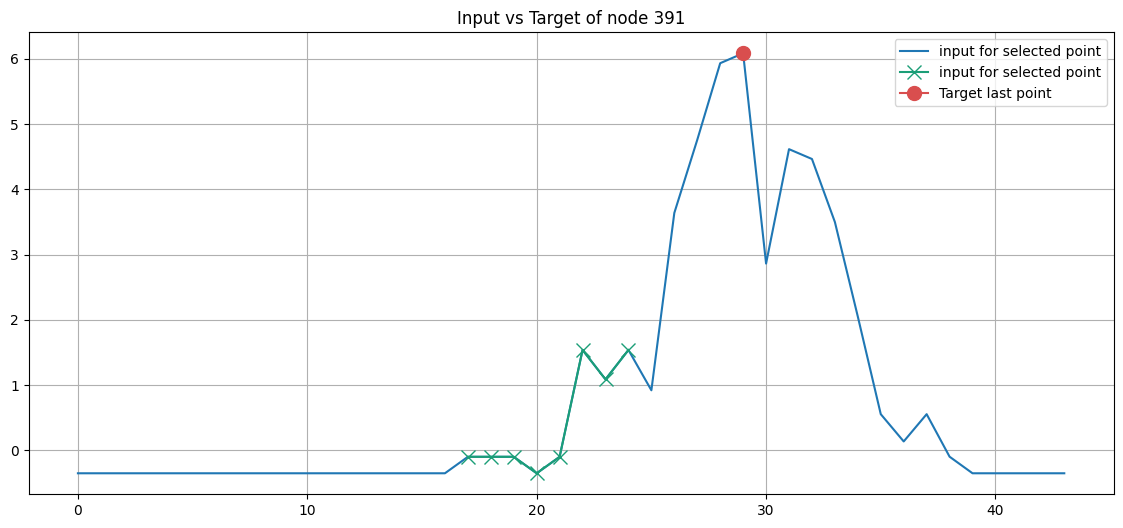

In [2]:
n_periods = 8
n_epochs  = 25
horizon   = 1
lags      = range(4,5)


epidata = EpiDataLoader('influenza', data_env, aggr_level= '03', min_date='2012-06-01',max_date='2020-06-01')
# epidata.add_time_features()
epidata.log_transform_target()
epidata.normalize('2018-06-01','2019-06-01','zscore')
epidata.add_lagged_features(lags = lags)


gnnloader1 = GNNDataLoader(epidata).retrieve_graph('identity_graph').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
gnnloader2 = GNNDataLoader(epidata).retrieve_graph('gravity_model_log').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
gnnloader3 = GNNDataLoader(epidata).retrieve_graph('gravity_model_top8_log').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
gnnloader1.preview_dataloader(391, 29)

idgraph_losses = []
ggraph1_losses  = []
ggraph2_losses  = []

for trial in range(1):
    # boolean neighbors
    tGCN_idgraph = TemporalGCNModel(name = f'identity_graph_{trial}', dataloader=gnnloader1)
    tGCN_idgraph.set_model_hparams()
    tGCN_idgraph.set_global_hparams(lr = 0.00005, n_epochs=n_epochs, scheduler_kwargs={'step_size':15}, min_delta = 0.1)
    tGCN_idgraph.train()
    tGCN_idgraph.forecast()
    tGCN_idgraph.show_forecasts()
    idgraph_losses.append(tGCN_idgraph.test_loss)

    # gravity 1
    tGCN_ggraph1 = TemporalGCNModel(name = f'gravit_model_log_{trial}', dataloader=gnnloader2)
    tGCN_ggraph1.set_model_hparams()
    tGCN_ggraph1.set_global_hparams(lr = 0.00005, n_epochs=n_epochs, scheduler_kwargs={'step_size':15}, min_delta = 0.1)
    tGCN_ggraph1.train()
    tGCN_ggraph1.forecast()
    tGCN_ggraph1.show_forecasts()
    ggraph1_losses.append(tGCN_ggraph1.test_loss)

    # gravity 2
    tGCN_ggraph2 = TemporalGCNModel(name = f'gravit_model_log_{trial}', dataloader=gnnloader3)
    tGCN_ggraph2.set_model_hparams()
    tGCN_ggraph2.set_global_hparams(lr = 0.00005, n_epochs=n_epochs, scheduler_kwargs={'step_size':15}, min_delta = 0.1)
    tGCN_ggraph2.train()
    tGCN_ggraph2.forecast()
    tGCN_ggraph2.show_forecasts()
    ggraph2_losses.append(tGCN_ggraph2.test_loss)


fig, axes = plt.subplots(1,3, figsize = (8,3))
axes = axes.flatten()

sns.histplot(idgraph_losses, label = 'id graph', ax = axes[0])
sns.histplot(ggraph1_losses, label = 'gg graph1', ax = axes[1], color = 'orange')
sns.histplot(ggraph2_losses, label = 'gg graph2', ax = axes[2], color = 'green')
fig.legend()
    


## MULTI STEP

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


Dataloader Snapshot: Data(x=[411, 2, 8], edge_index=[2, 411], y=[411, 4], edge_weight=[411])
Epoch 1 train loss: 5.1785, val loss: 10.5633 ✓ (new best)
Test loss: 11.8637
Dataloader Snapshot: Data(x=[411, 2, 8], edge_index=[2, 4255], y=[411, 4], edge_weight=[4255])
Epoch 1 train loss: 5.2102, val loss: 10.7942 ✓ (new best)
Test loss: 12.1035
Dataloader Snapshot: Data(x=[411, 2, 8], edge_index=[2, 3695], y=[411, 4], edge_weight=[3695])
Epoch 1 train loss: 5.0672, val loss: 10.3343 ✓ (new best)
Test loss: 11.6068


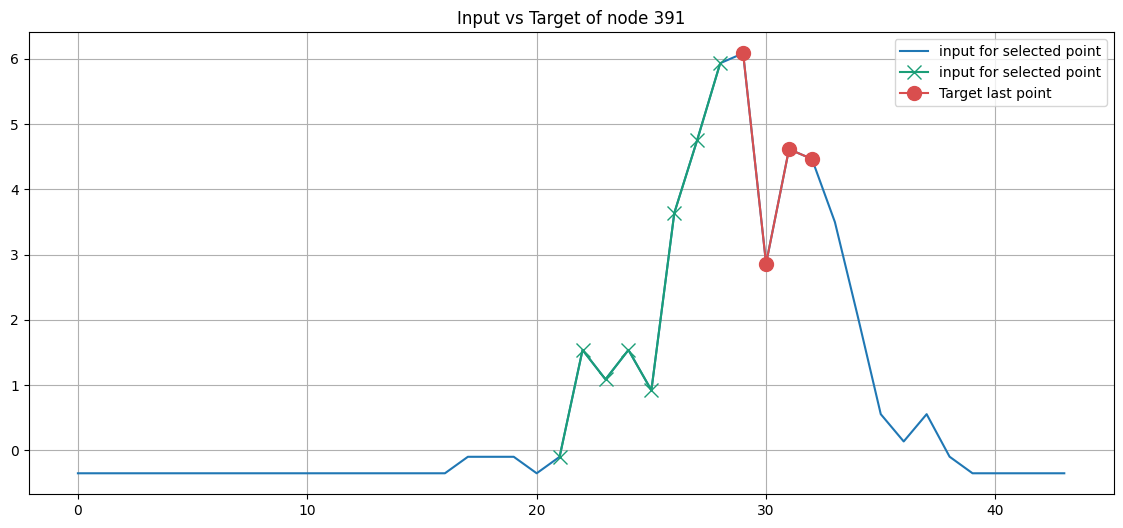

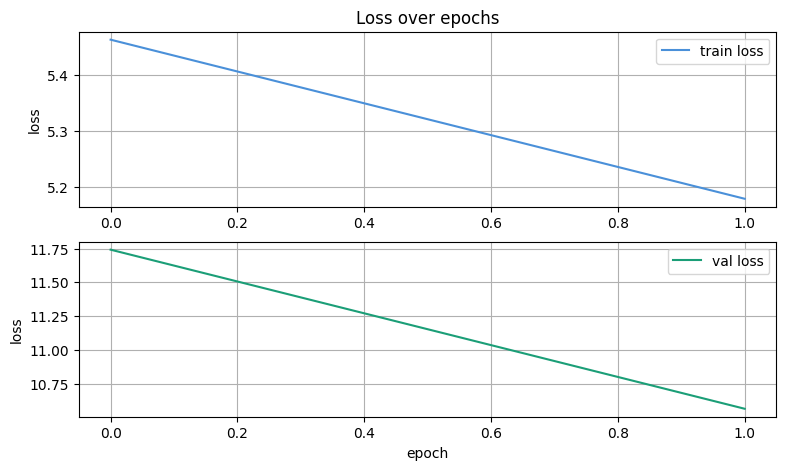

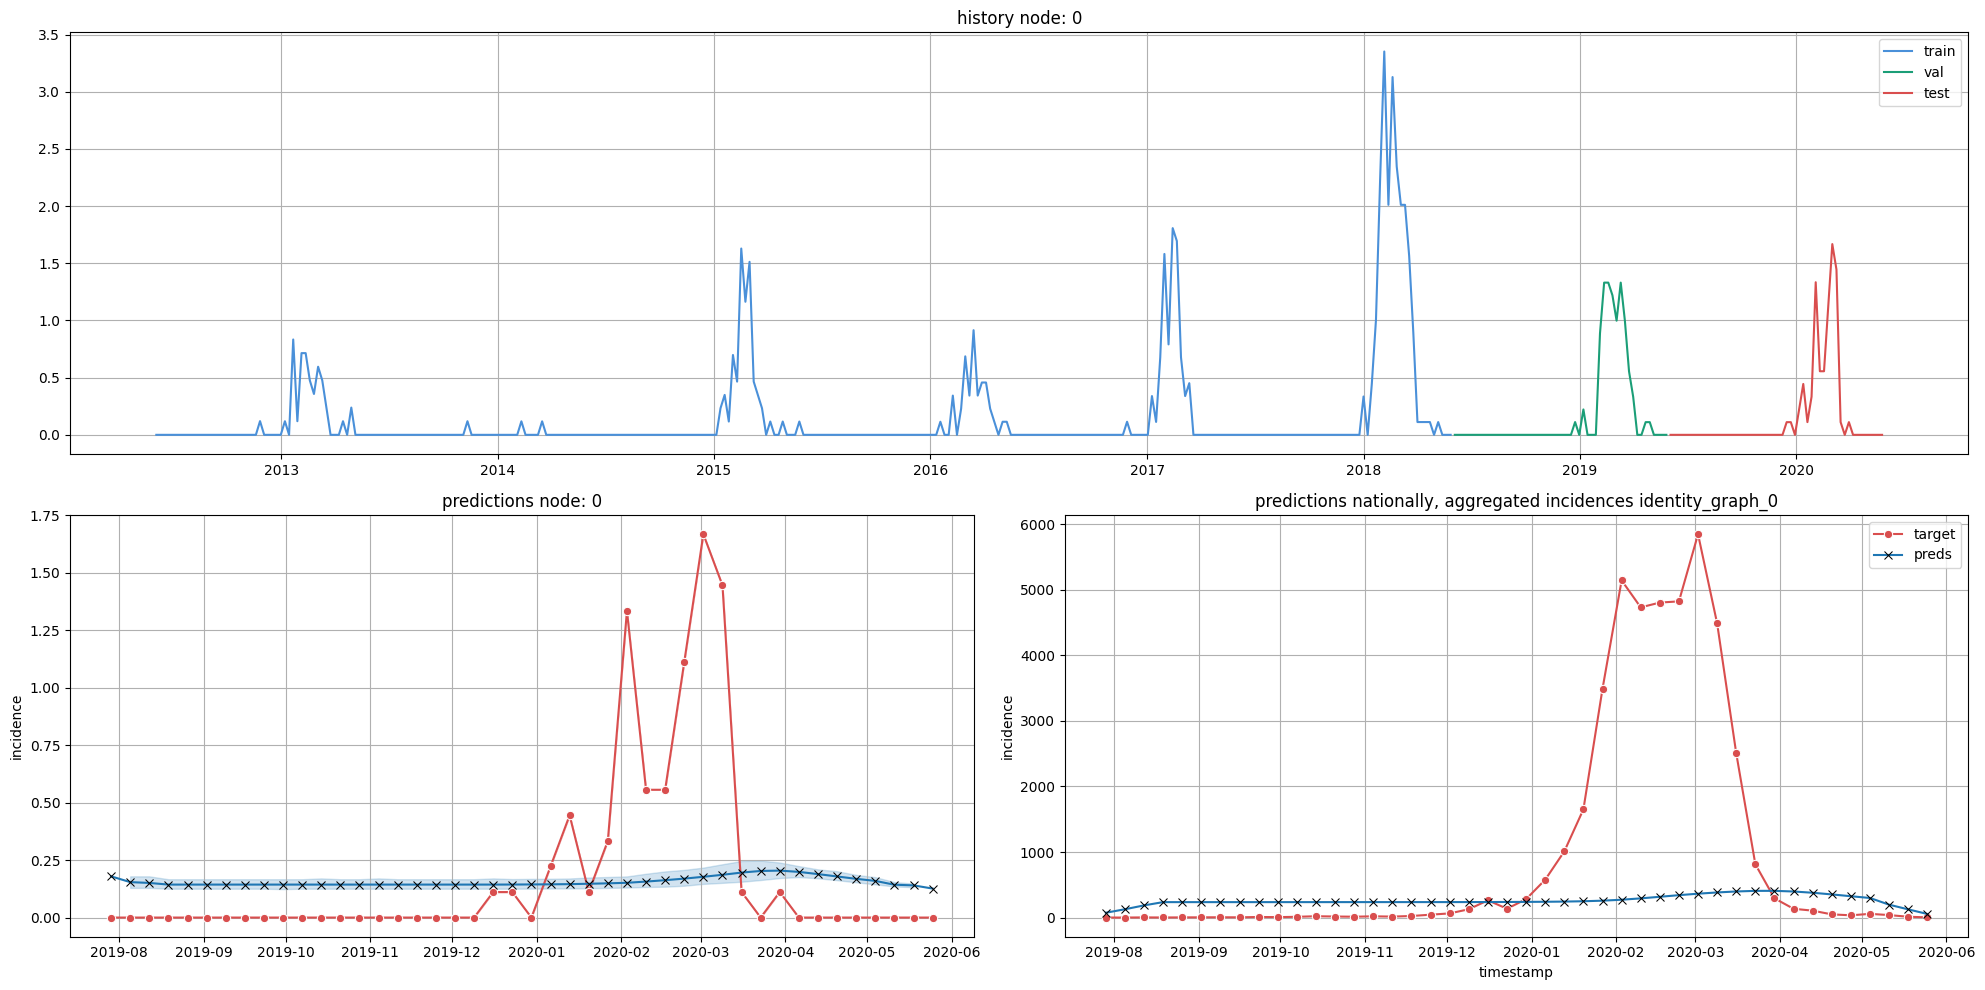

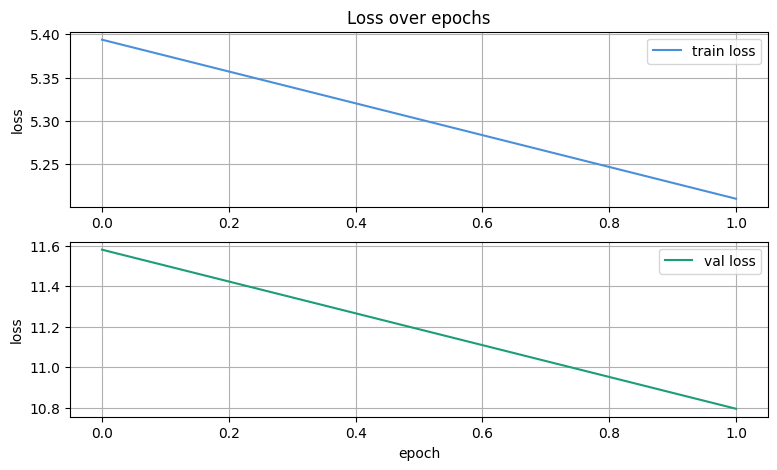

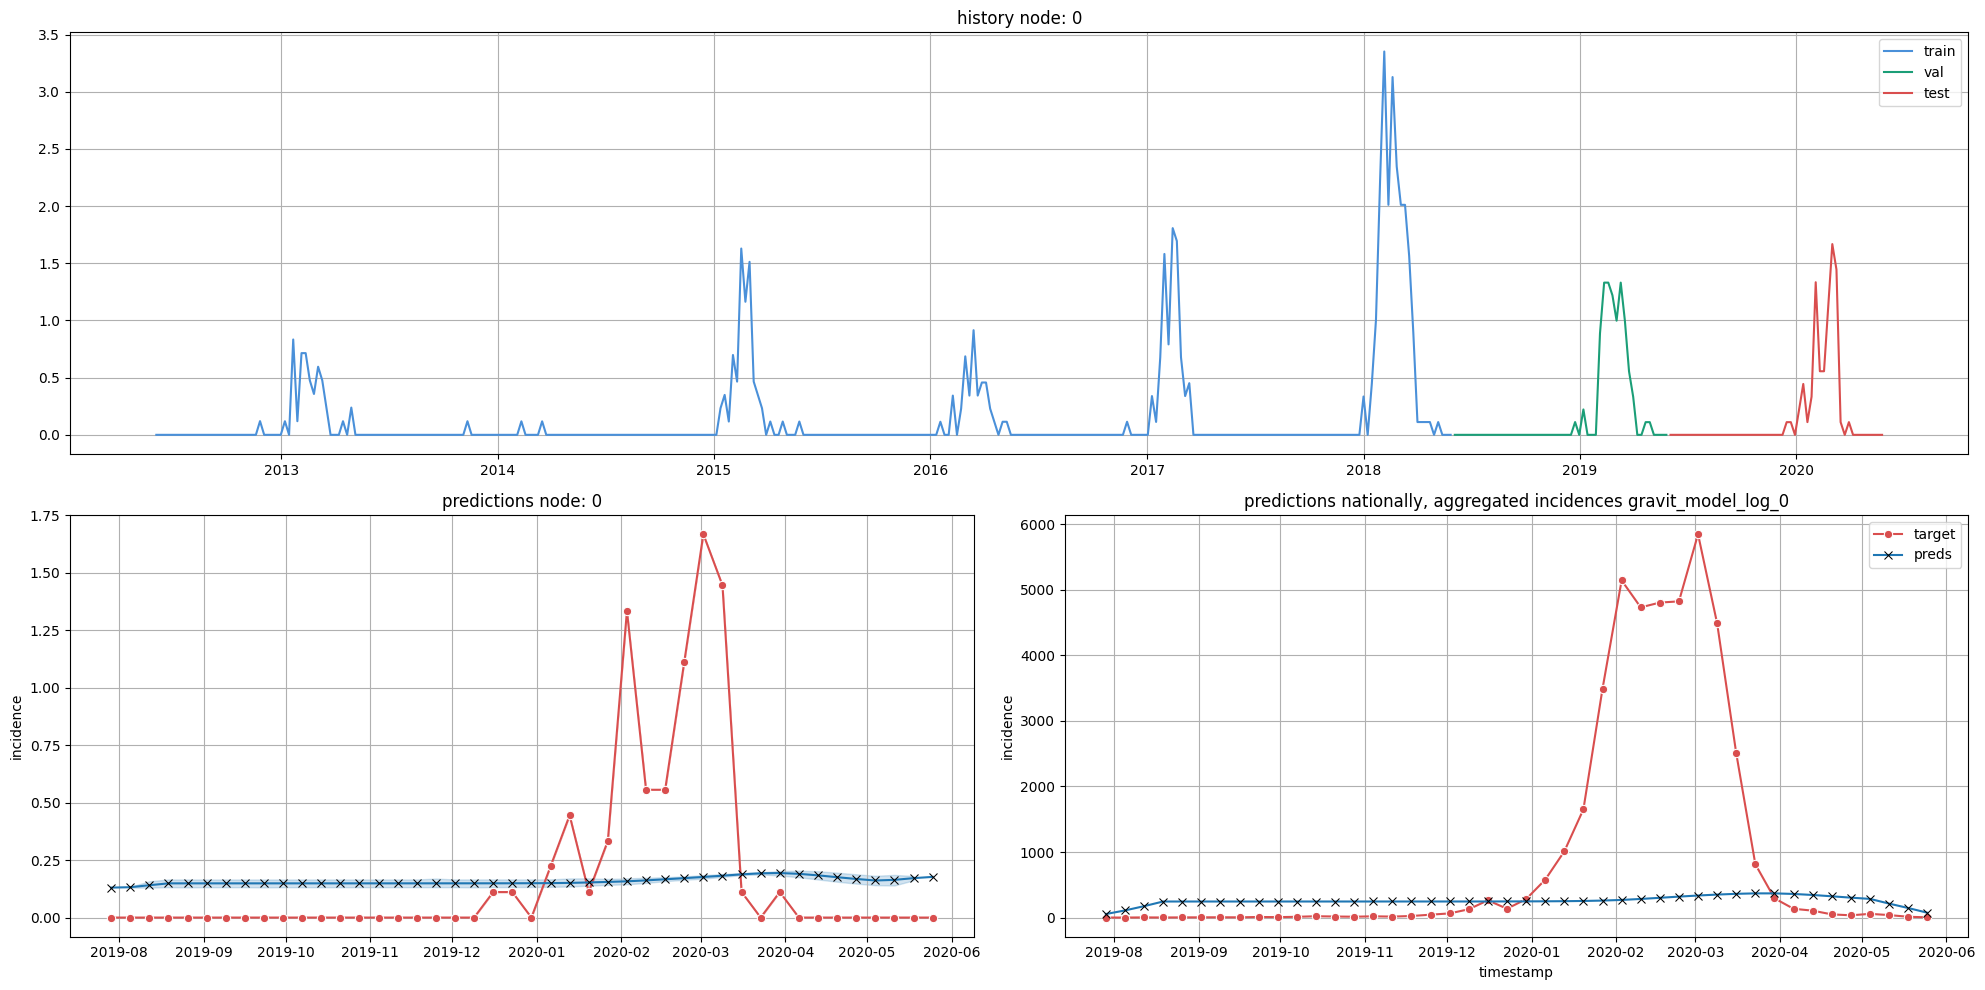

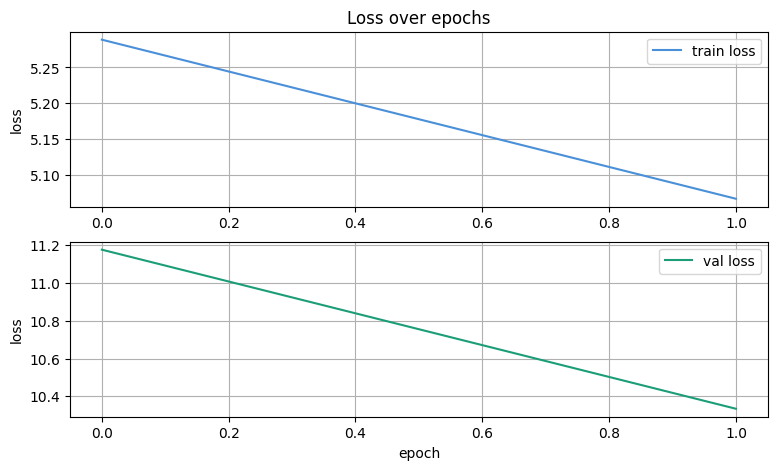

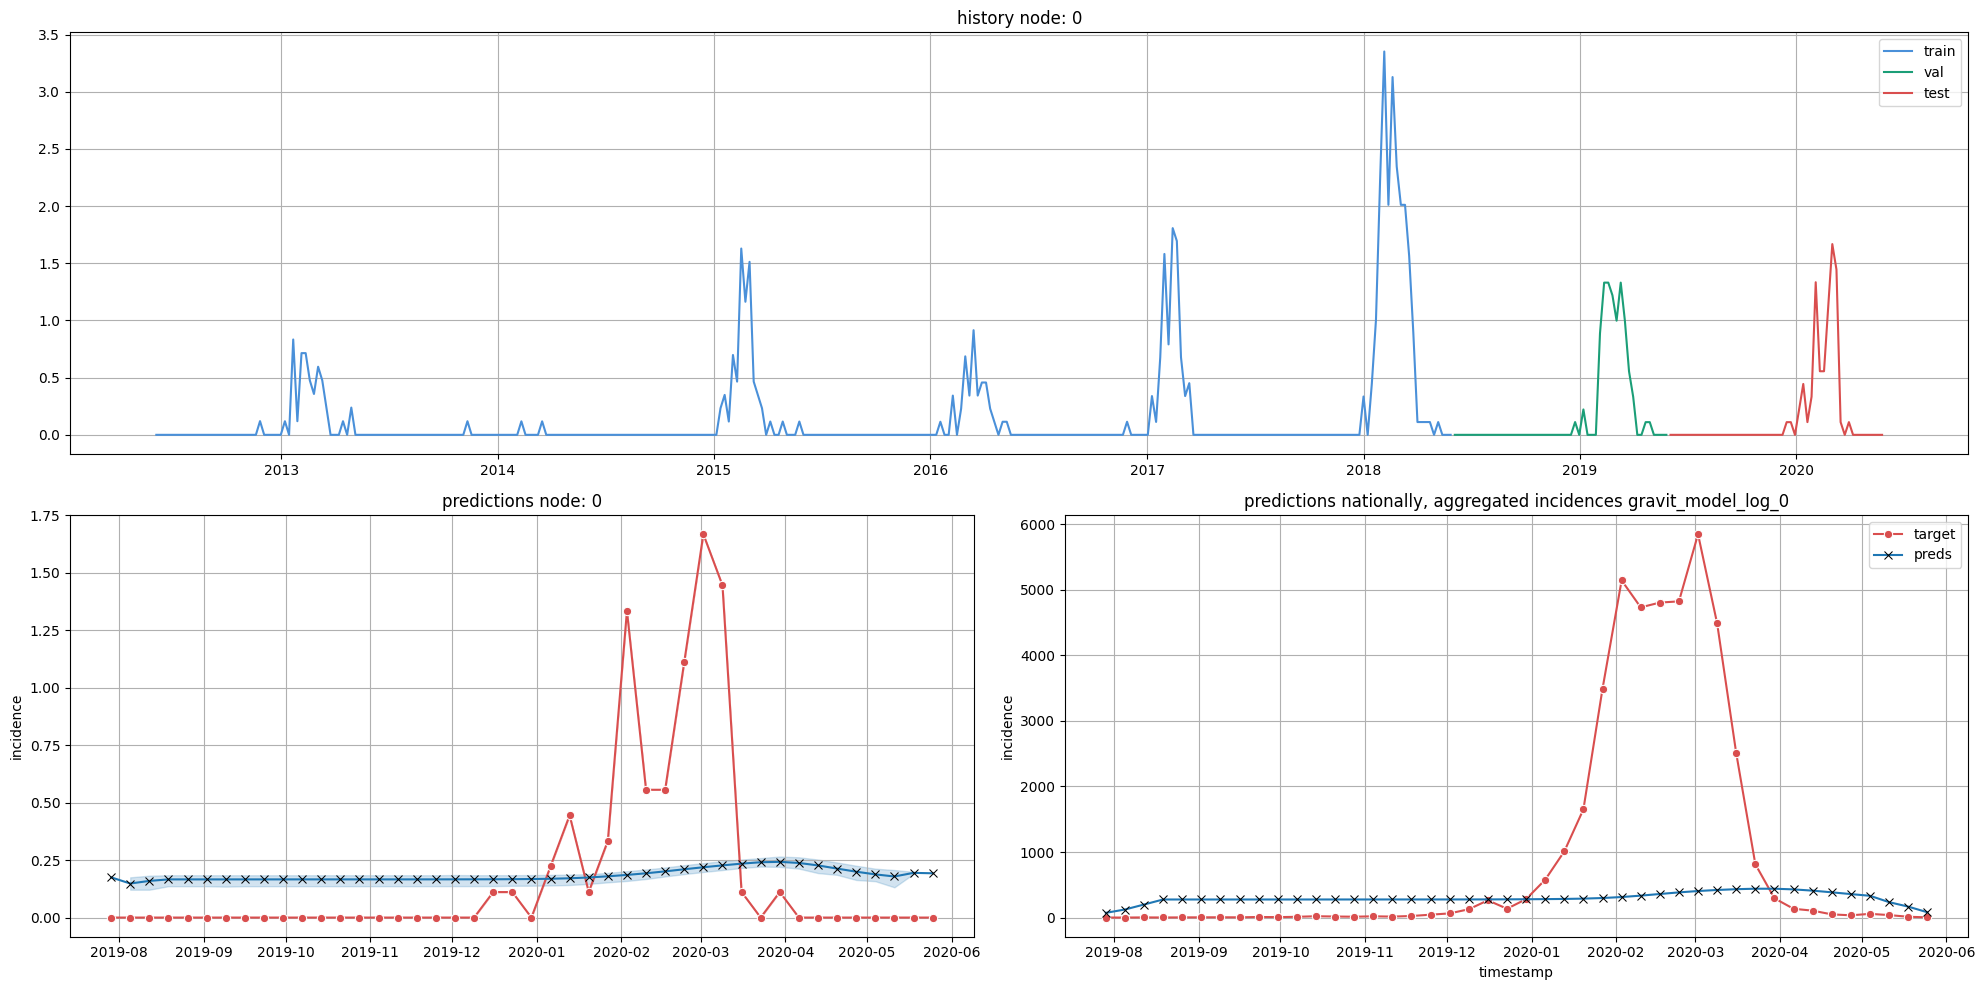

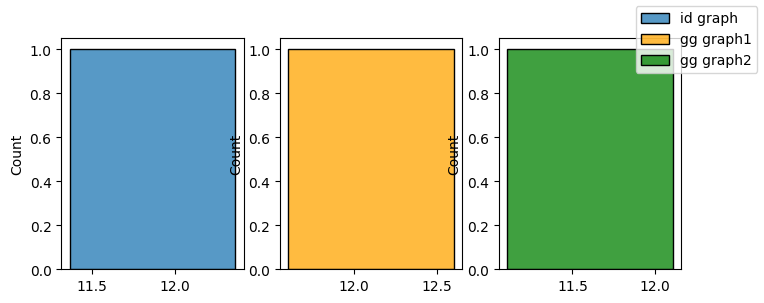

In [2]:
n_periods = 8
n_epochs  = 2
horizon   = 4
lags      = range(0,1)


epidata = EpiDataLoader('influenza', data_env, aggr_level= '03', min_date='2012-06-01',max_date='2020-06-01')
# epidata.add_time_features()
epidata.log_transform_target()
epidata.normalize('2018-06-01','2019-06-01','zscore')
epidata.add_lagged_features(lags = lags)


gnnloader1 = GNNDataLoader(epidata).retrieve_graph('identity_graph').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
gnnloader2 = GNNDataLoader(epidata).retrieve_graph('gravity_model_log').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
gnnloader3 = GNNDataLoader(epidata).retrieve_graph('gravity_model_top8_log').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
gnnloader1.preview_dataloader(391, 29)

idgraph_losses = []
ggraph1_losses  = []
ggraph2_losses  = []

for trial in range(1):
    # boolean neighbors
    tGCN_idgraph = TemporalGCNModel(name = f'identity_graph_{trial}', dataloader=gnnloader1)
    tGCN_idgraph.set_model_hparams()
    tGCN_idgraph.set_global_hparams(lr = 0.00005, n_epochs=n_epochs, scheduler_kwargs={'step_size':15}, min_delta = 0.1)
    tGCN_idgraph.train()
    tGCN_idgraph.forecast()
    tGCN_idgraph.show_forecasts()
    idgraph_losses.append(tGCN_idgraph.test_loss)

    # gravity 1
    tGCN_ggraph1 = TemporalGCNModel(name = f'gravit_model_log_{trial}', dataloader=gnnloader2)
    tGCN_ggraph1.set_model_hparams()
    tGCN_ggraph1.set_global_hparams(lr = 0.00005, n_epochs=n_epochs, scheduler_kwargs={'step_size':15}, min_delta = 0.1)
    tGCN_ggraph1.train()
    tGCN_ggraph1.forecast()
    tGCN_ggraph1.show_forecasts()
    ggraph1_losses.append(tGCN_ggraph1.test_loss)

    # gravity 2
    tGCN_ggraph2 = TemporalGCNModel(name = f'gravit_model_log_{trial}', dataloader=gnnloader3)
    tGCN_ggraph2.set_model_hparams()
    tGCN_ggraph2.set_global_hparams(lr = 0.00005, n_epochs=n_epochs, scheduler_kwargs={'step_size':15}, min_delta = 0.1)
    tGCN_ggraph2.train()
    tGCN_ggraph2.forecast()
    tGCN_ggraph2.show_forecasts()
    ggraph2_losses.append(tGCN_ggraph2.test_loss)


fig, axes = plt.subplots(1,3, figsize = (8,3))
axes = axes.flatten()

sns.histplot(idgraph_losses, label = 'id graph', ax = axes[0])
sns.histplot(ggraph1_losses, label = 'gg graph1', ax = axes[1], color = 'orange')
sns.histplot(ggraph2_losses, label = 'gg graph2', ax = axes[2], color = 'green')
fig.legend()
    
